# CMNIST generator-correction study

This notebook loads a completed backend run, presents the precomputed independent and OT results, and reconstructs saved correction checkpoints for fresh inference.


In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torchvision.utils import make_grid

_here = Path.cwd().resolve()
REPO_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "deconfoundingfm").exists())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from deconfoundingfm.experimental import (
    load_cmnist_correction_checkpoint,
    load_result_bundle,
)

RESULT_DIR = Path(os.environ.get(
    "CMNIST_RESULT_DIR",
    REPO_ROOT / "examples" / "cmnist" / "results" / "default",
)).resolve()
bundle = load_result_bundle(RESULT_DIR)
config = bundle["config"]
print("Result directory:", RESULT_DIR)
print("Evaluation samples per arm:", config["eval_n"])
print("Saved bundle keys:", sorted(bundle))


Result directory: /nfs/ghome/live/danceh/DeconfoundingFlowMatching/examples/cmnist/results/default
Evaluation samples per arm: 5000
Saved bundle keys: ['color_diagnostics', 'color_values', 'config', 'convergence', 'data_manifest', 'manifest', 'metrics', 'model_manifest', 'path', 'samples', 'trajectories', 'trajectory_summary']


## Final sliced-Wasserstein metrics

SW2 is computed separately for each treatment arm and then averaged. Every method uses the same random projection directions.


In [2]:
metrics = bundle["metrics"]
rows = [
    {"method": method, "SW2": metrics[f"{method}_sw2"]}
    for method in ("source", "decfm", "ot")
]
display(pd.DataFrame(rows))
print(
    "n per arm:", metrics["evaluation_n_per_arm"],
    "| SW2 projections:", metrics["sw2_projections"],
)


,method,SW2
0,source,0.032277
1,decfm,0.026770
2,ot,0.013757


n per arm: 5000 | SW2 projections: 256


## Generated samples

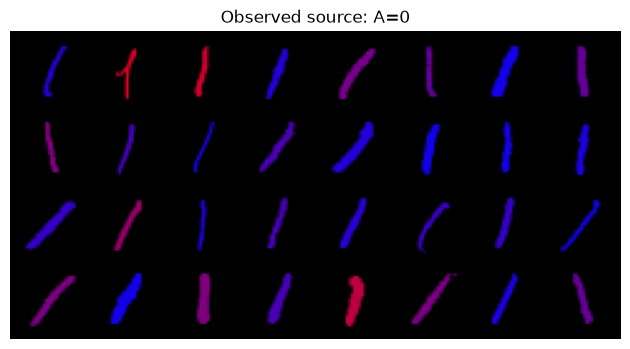

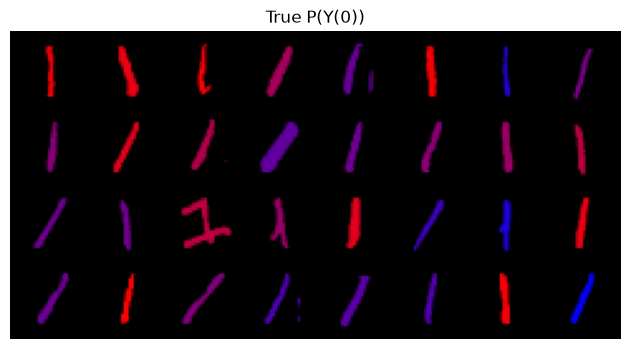

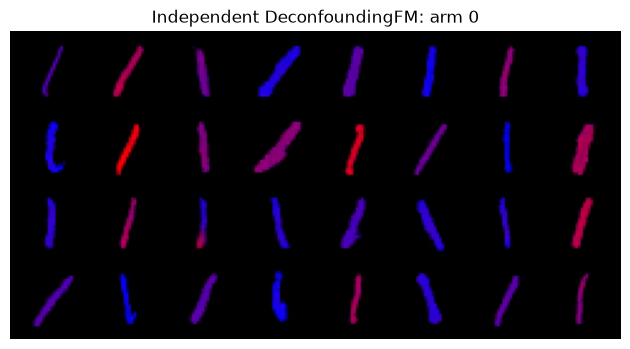

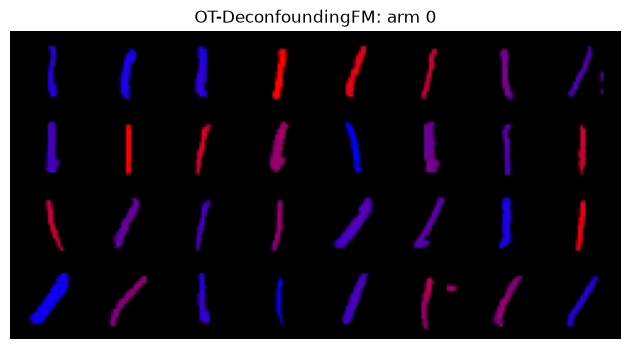

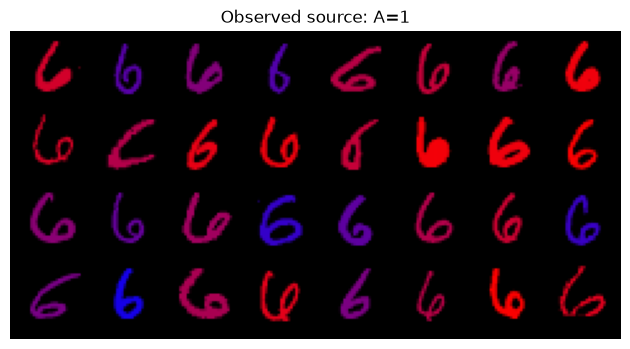

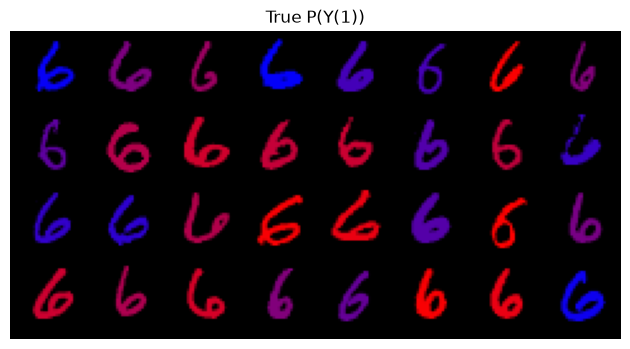

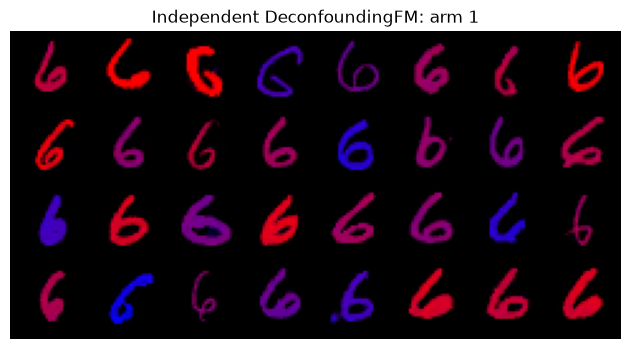

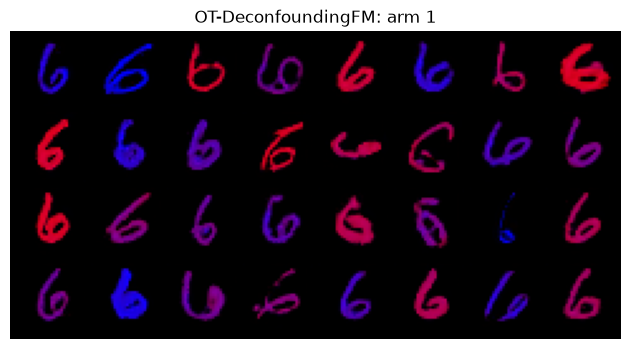

In [3]:
samples = bundle["samples"]

def show_grid(images, title, n=32, nrow=8):
    grid = make_grid(images[:n].clamp(0, 1), nrow=nrow).permute(1, 2, 0).cpu()
    plt.figure(figsize=(8, 4))
    plt.imshow(grid)
    plt.title(title)
    plt.axis("off")
    plt.show()

for key, title in (
    ("observed_a0", "Observed source: A=0"),
    ("true_a0", "True P(Y(0))"),
    ("decfm_a0", "Independent DeconfoundingFM: arm 0"),
    ("ot_a0", "OT-DeconfoundingFM: arm 0"),
    ("observed_a1", "Observed source: A=1"),
    ("true_a1", "True P(Y(1))"),
    ("decfm_a1", "Independent DeconfoundingFM: arm 1"),
    ("ot_a1", "OT-DeconfoundingFM: arm 1"),
):
    show_grid(samples[key], title)


## SW2 convergence by saved checkpoint

Every point uses the same deterministic 512-image truth set and the same generator-base batch in each arm, as well as common projection directions. Differences across steps therefore reflect the saved correction weights rather than new base draws.


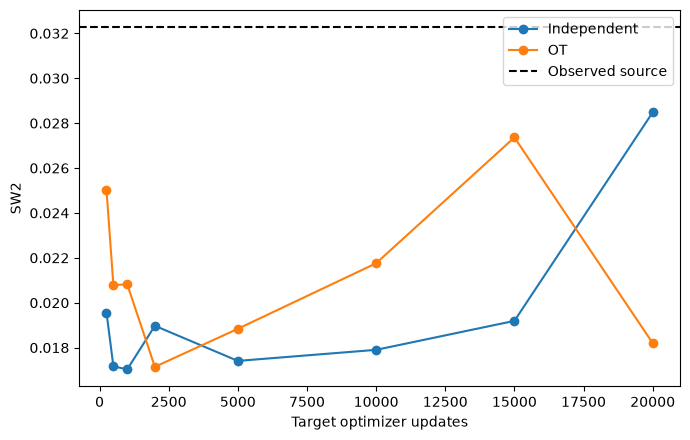

In [4]:
convergence = bundle["convergence"]
plt.figure(figsize=(7, 4.5))
plt.plot(convergence["steps"], convergence["decfm"], marker="o", label="Independent")
plt.plot(convergence["steps"], convergence["ot"], marker="o", label="OT")
plt.axhline(metrics["source_sw2"], linestyle="--", color="black", label="Observed source")
plt.xlabel("Target optimizer updates")
plt.ylabel("SW2")
plt.legend()
plt.tight_layout()
plt.show()


## Learned color distributions \(P(X(a))\)

For each generated image, color is recovered as total foreground red mass divided by total foreground red-plus-blue mass, matching the paper's \(R/(R+B)\) transformation. The causal target is uniform for both arms.


In [5]:
color_diag = bundle["color_diagnostics"]
display(pd.DataFrame([{"method": method, **values} for method, values in color_diag.items()]))


,method,arm0_vs_arm1_w1,arm0_vs_uniform_w1,arm1_vs_uniform_w1,arm0_vs_uniform_ks,arm1_vs_uniform_ks,n_images_arm0,n_images_arm1
0,source,0.320365,0.158743,0.161622,0.252837,0.250202,5000,5000
1,truth,0.010501,0.003949,0.007528,0.010988,0.016560,5000,5000
2,decfm,0.268327,0.129446,0.139341,0.220504,0.217294,5000,5000
3,ot,0.086482,0.063912,0.030453,0.112254,0.048871,5000,5000


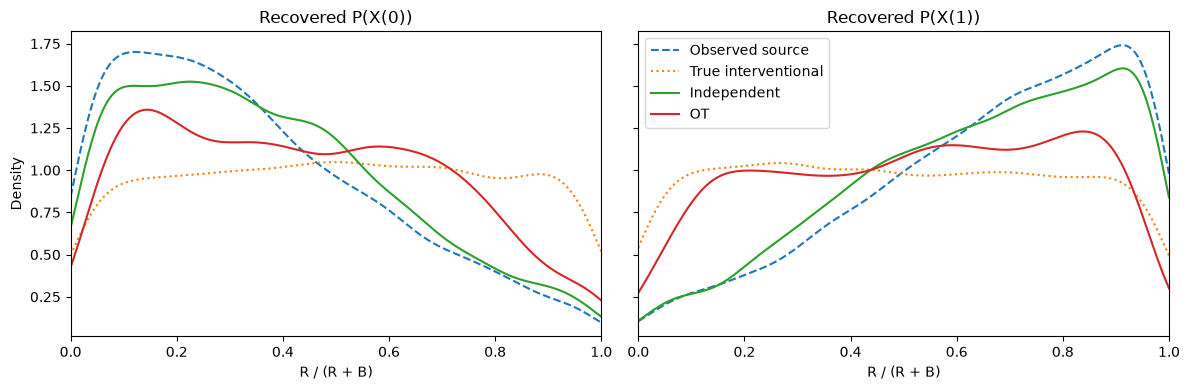

In [6]:
color_values = bundle["color_values"]

def kde(values, grid):
    values = values[torch.isfinite(values)].float()
    bandwidth = max(1.06 * float(values.std(unbiased=False)) * len(values) ** (-0.2), 0.015)
    z = (grid[:, None] - values[None, :]) / bandwidth
    density = torch.exp(-0.5 * z.square()).mean(dim=1) / (bandwidth * (2 * torch.pi) ** 0.5)
    return density

grid = torch.linspace(0, 1, 300)
styles = {
    "source": {"label": "Observed source", "linestyle": "--"},
    "truth": {"label": "True interventional", "linestyle": ":"},
    "decfm": {"label": "Independent", "linestyle": "-"},
    "ot": {"label": "OT", "linestyle": "-"},
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for arm, ax in enumerate(axes):
    for method, style in styles.items():
        values = color_values[method][f"arm{arm}"]
        ax.plot(grid, kde(values, grid), **style)
    ax.set_title(f"Recovered P(X({arm}))")
    ax.set_xlabel("R / (R + B)")
    ax.set_xlim(0, 1)
axes[0].set_ylabel("Density")
axes[1].legend()
plt.tight_layout()
plt.show()


## Flow-change and path diagnostics

A shared batch of 512 fresh source images per arm is transformed by both methods. Endpoint change is measured only over source-digit foreground pixels. Full trajectories are retained for the top- and bottom-changing examples.


In [7]:
trajectory_summary = bundle["trajectory_summary"]
rows = []
for method in ("decfm", "ot"):
    rows.append({"method": method, **trajectory_summary[method]["average_over_arms"]})
display(pd.DataFrame(rows))


,method,mean_foreground_pixel_change,mean_path_length,mean_endpoint_displacement,mean_straightness_ratio,mean_bar_E_v,mean_bar_E_vdot,dimension,n_trajectories_per_arm
0,decfm,0.026343,0.122539,0.01685,10.047940,0.016650,1.115060,2352,512
1,ot,0.072831,0.060543,0.04428,1.529689,0.004477,0.067015,2352,512


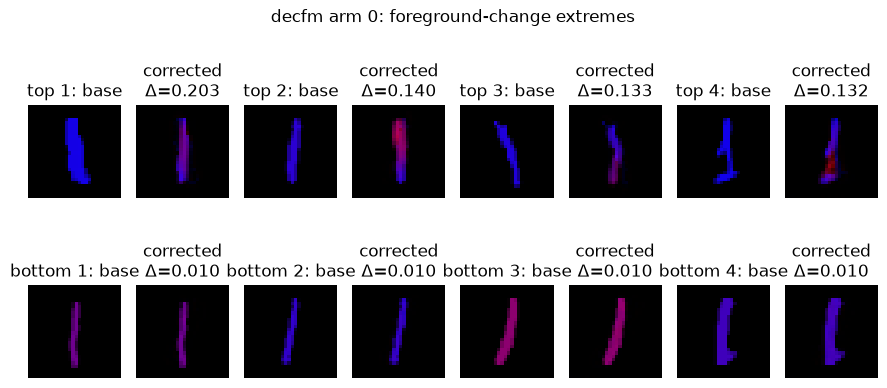

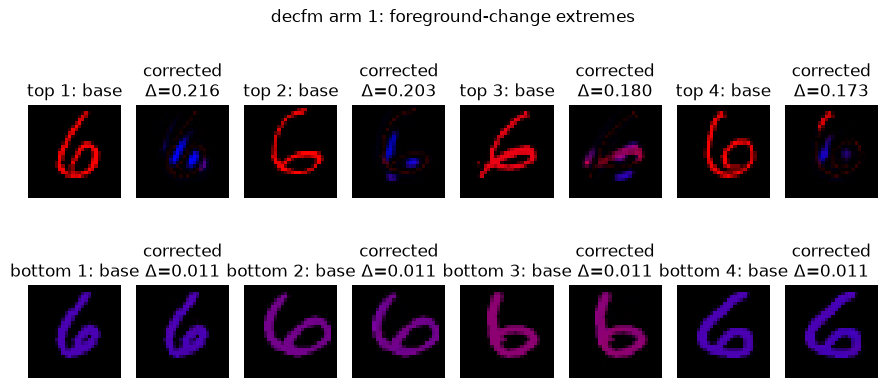

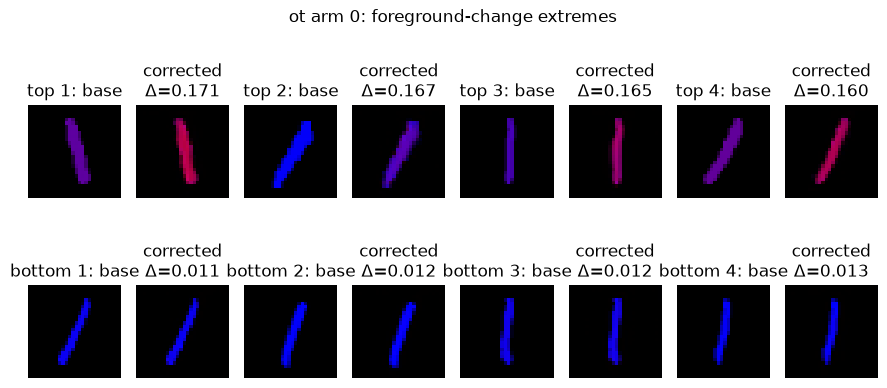

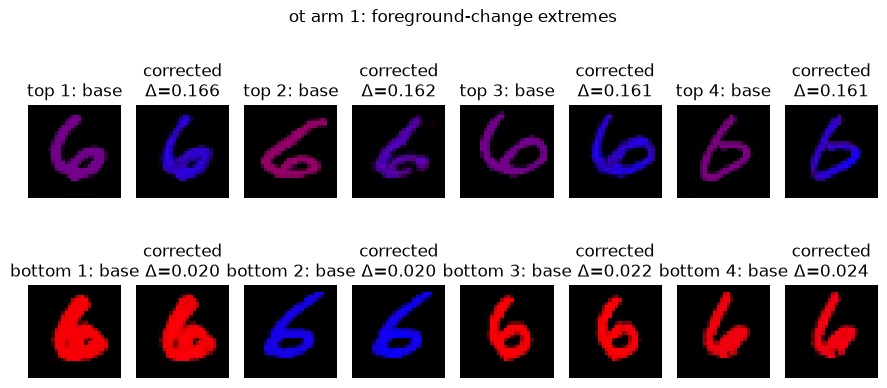

In [8]:
trajectories = bundle["trajectories"]

def show_change_extremes(method, arm, keep=4):
    record = trajectories[method][f"arm{arm}"]
    fig, axes = plt.subplots(2, 2 * keep, figsize=(2.2 * keep, 4.5))
    for row, extreme in enumerate(("top", "bottom")):
        selected = record[extreme]
        sequence = selected["trajectory"]
        scores = selected["foreground_pixel_change"]
        for j in range(min(keep, sequence.shape[1])):
            axes[row, 2*j].imshow(sequence[0, j].permute(1, 2, 0).clamp(0, 1))
            axes[row, 2*j].set_title(f"{extreme} {j+1}: base")
            axes[row, 2*j+1].imshow(sequence[-1, j].permute(1, 2, 0).clamp(0, 1))
            axes[row, 2*j+1].set_title(f"corrected\nΔ={scores[j]:.3f}")
        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle(f"{method} arm {arm}: foreground-change extremes")
    plt.tight_layout()
    plt.show()

for method in ("decfm", "ot"):
    for arm in (0, 1):
        show_change_extremes(method, arm)


## Selected full trajectories

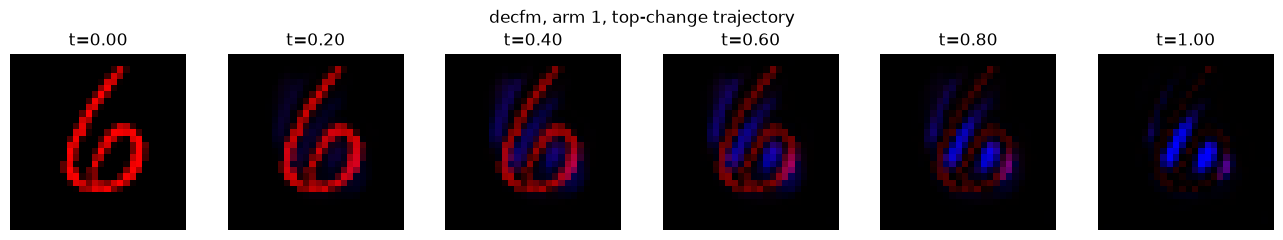

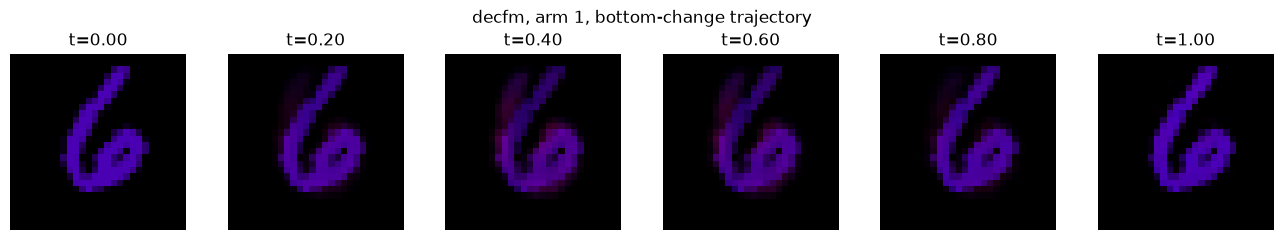

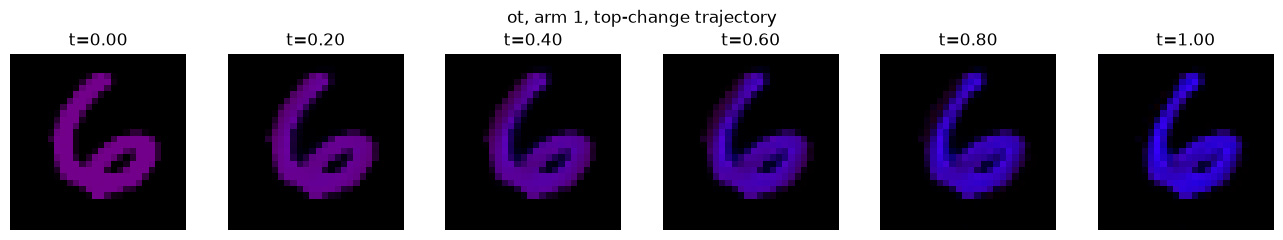

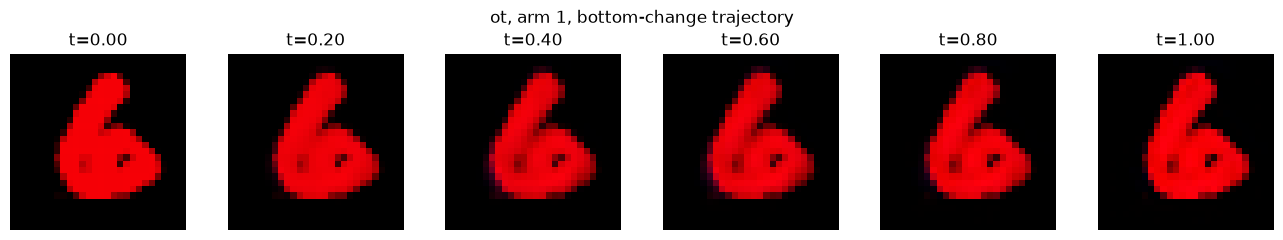

In [9]:
def show_saved_trajectory(method, arm, extreme="top", rank=0, frames=6):
    sequence = trajectories[method][f"arm{arm}"][extreme]["trajectory"][:, rank]
    indices = torch.linspace(0, len(sequence) - 1, frames).long()
    fig, axes = plt.subplots(1, frames, figsize=(2.2 * frames, 2.4))
    for ax, index in zip(axes, indices):
        ax.imshow(sequence[index].permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"t={index.item()/(len(sequence)-1):.2f}")
        ax.axis("off")
    fig.suptitle(f"{method}, arm {arm}, {extreme}-change trajectory")
    plt.tight_layout()
    plt.show()

for method in ("decfm", "ot"):
    show_saved_trajectory(method, arm=1, extreme="top")
    show_saved_trajectory(method, arm=1, extreme="bottom")


## Fresh inference from a saved checkpoint

This cell reconstructs the exact CMNIST source generator and correction velocity from the portable manifest. It does not load nuisance models, propensity fits, plug-in reservoirs, or cached base samples.


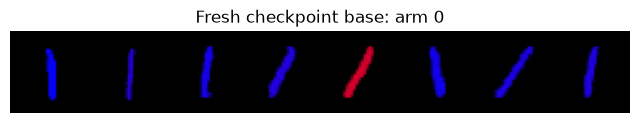

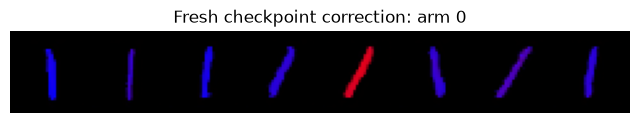

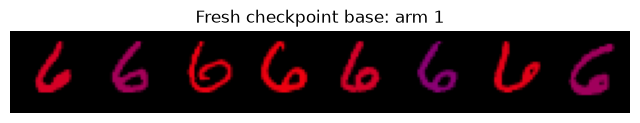

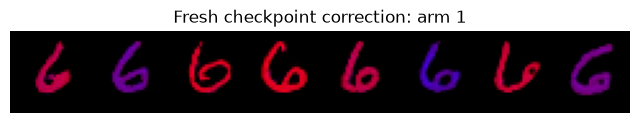

Loaded examples/cmnist/results/default/models/ot/step_020000.pt on cuda


In [10]:
model_manifest = bundle["model_manifest"]
INFERENCE_METHOD = "ot"
model_entry = model_manifest["models"][INFERENCE_METHOD]
INFERENCE_STEP = str(model_entry["final_step"])
checkpoint_path = RESULT_DIR / model_entry["checkpoints"][INFERENCE_STEP]
INFERENCE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sampler = load_cmnist_correction_checkpoint(checkpoint_path, device=INFERENCE_DEVICE)
torch.manual_seed(config["seed"] + 9000)
fresh = {}
for arm in (0, 1):
    y0, y1 = sampler.sample(arm, 8, return_base=True)
    fresh[arm] = {"base": y0.cpu(), "corrected": y1.cpu()}
    show_grid(y0.cpu(), f"Fresh checkpoint base: arm {arm}", n=8)
    show_grid(y1.cpu(), f"Fresh checkpoint correction: arm {arm}", n=8)
print("Loaded", checkpoint_path.relative_to(REPO_ROOT), "on", INFERENCE_DEVICE)


In [11]:
# Fresh trajectories can be generated from arbitrary fresh or user-supplied bases.
fresh_trajectory, fresh_midpoint_velocities = sampler.trajectory(
    arm=1, y0=fresh[1]["base"][:2].to(INFERENCE_DEVICE)
)
print("trajectory shape:", tuple(fresh_trajectory.shape))
print("midpoint velocity shape:", tuple(fresh_midpoint_velocities.shape))


trajectory shape: (51, 2, 3, 28, 28)
midpoint velocity shape: (50, 2, 3, 28, 28)


## Reconstructing the observational population

The exact fixed observational population is reproducible from the packaged MNIST UByte files, saved DGP configuration, and observational seed. Set the flag below when the full tensors are needed for a post-hoc analysis.


In [12]:
RECREATE_OBSERVATIONAL_DATA = False
if RECREATE_OBSERVATIONAL_DATA:
    observational = sampler.recreate_observational_population(device="cpu")
    print({key: tuple(value.shape) for key, value in observational.items() if isinstance(value, torch.Tensor)})
else:
    print(json.dumps(bundle["data_manifest"], indent=2))


{
  "reconstruction": "ColorMNISTDGP(CMNISTConfig(**dgp_config)).make_observational_population(seed=observational_seed)",
  "observational_seed": 0,
  "dgp_config": {
    "digits": [
      1,
      6
    ],
    "x_low": 0.0,
    "x_high": 1.0,
    "propensity_w": 5.0,
    "tau": 0.08,
    "k": 10.0,
    "fg_alpha": 0.0,
    "n_bw_shapes": 10000,
    "color_draws_per_shape": 2
  },
  "observational_n": 20000,
  "direct_observational_tensor_saved": false,
  "source_generator": "ExactColorMNISTSourceGenerator",
  "fresh_base_samples_available": true
}
